Highest epoch saved is 2000


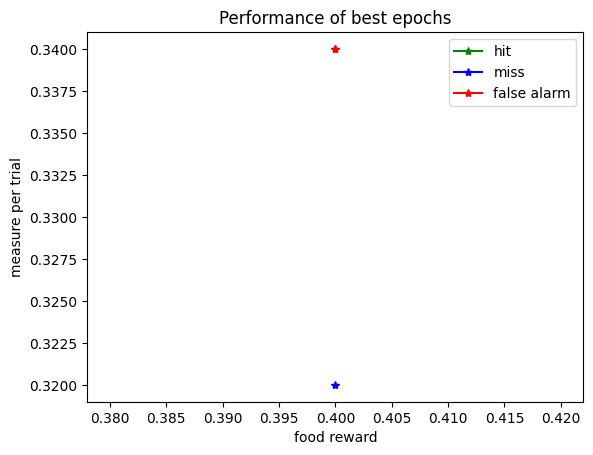

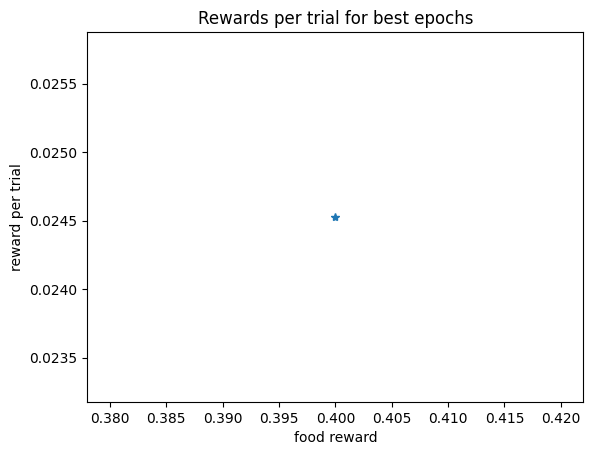

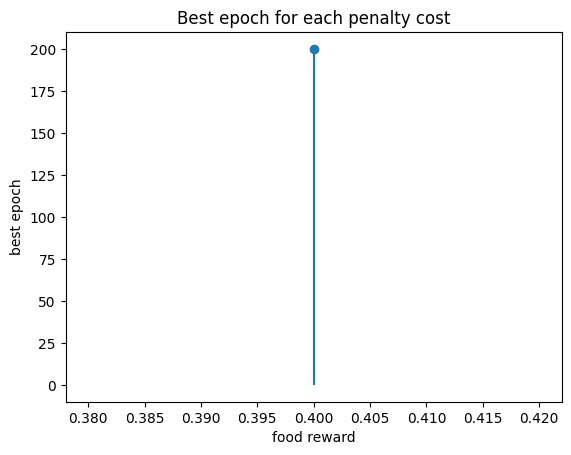

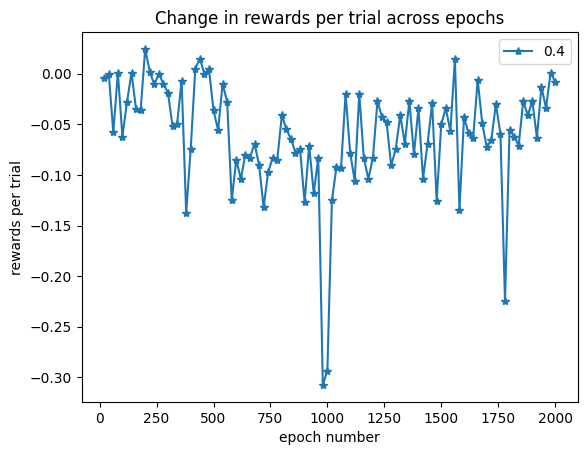

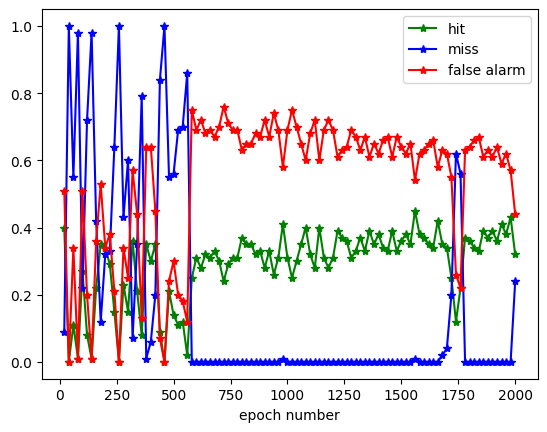

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from auditoryforage.utils import open_pickle_file, find_recent_epoch
folder_name = './store/comparison/'
pattern = 'across_penalty_#seeds_1_#epochs_'
start_model_no = 0
epoch_increments_saved = 20
max_epoch_val = find_recent_epoch(directory = folder_name, pattern = pattern)
num_models = int(max_epoch_val/epoch_increments_saved)

def setup_matrix_across_epochs(start_model_no, num_models, measure):
    # rows are different epochs.
    # cols are corresp. different exp no.

    epochs_list =  [(elt + 1) * epoch_increments_saved for elt in range(start_model_no, num_models)]

    matrix_across_epochs = []
    for epoch in epochs_list:
        file_name = folder_name + f'across_penalty_#seeds_1_#epochs_{epoch}.pkl'
        detection_measures = open_pickle_file(file_name)
        matrix_across_epochs.append([curr_elt[0]/detection_measures['input']['no_episodes'] for curr_elt in detection_measures['output'][measure]])
    matrix_across_epochs = np.array(matrix_across_epochs)
    food_reward_list = detection_measures['input']['food_reward_list']
    return epochs_list, food_reward_list, matrix_across_epochs


epochs_list, food_reward_list, total_reward_matrix = setup_matrix_across_epochs(start_model_no, num_models, 'total_reward_list_across_exps')
best_epoch_list = np.argmax(total_reward_matrix,0)
_, _, hit_count_matrix = setup_matrix_across_epochs(start_model_no, num_models, 'hit_count_list')
_, _, miss_count_matrix = setup_matrix_across_epochs(start_model_no, num_models, 'miss_count_list')
_, _, false_alarm_matrix = setup_matrix_across_epochs(start_model_no, num_models, 'false_alarm_list')


plt.figure()
plt.plot(food_reward_list, [hit_count_matrix[epoch_ind][exp_ind] for epoch_ind, exp_ind in zip(best_epoch_list, range(len(best_epoch_list)))],'g*-')
plt.plot(food_reward_list, [miss_count_matrix[epoch_ind][exp_ind] for epoch_ind, exp_ind in zip(best_epoch_list, range(len(best_epoch_list)))],'b*-')
plt.plot(food_reward_list, [false_alarm_matrix[epoch_ind][exp_ind] for epoch_ind, exp_ind in zip(best_epoch_list, range(len(best_epoch_list)))],'r*-')
plt.legend(['hit', 'miss', 'false alarm'])
plt.xlabel('food reward')
plt.ylabel('measure per trial')
plt.title('Performance of best epochs')
plt.show()

plt.figure()
plt.plot(food_reward_list, [total_reward_matrix[epoch_ind][exp_ind] for epoch_ind, exp_ind in zip(best_epoch_list, range(len(best_epoch_list)))],'*-')
plt.xlabel('food reward')
plt.ylabel('reward per trial')
plt.title('Rewards per trial for best epochs')
plt.show()

plt.figure()
plt.stem(food_reward_list, [epochs_list[best_ind] for best_ind in best_epoch_list])
plt.xlabel('food reward')
plt.ylabel('best epoch')
plt.title('Best epoch for each penalty cost')
plt.show()

plt.figure()
for penalty_ind in range(len(food_reward_list)):
    plt.plot(epochs_list, [total_reward_matrix[epoch_ind][penalty_ind] for epoch_ind in range(len(epochs_list))],'*-')
plt.legend(food_reward_list)
plt.xlabel('epoch number')
plt.ylabel('rewards per trial')
plt.title('Change in rewards per trial across epochs')
plt.show()

plt.figure()
plt.plot(epochs_list, [elt[0] for elt in hit_count_matrix],'g-*')
plt.plot(epochs_list, [elt[0] for elt in miss_count_matrix],'b-*')
plt.plot(epochs_list, [elt[0] for elt in false_alarm_matrix],'r-*')
plt.legend(['hit','miss','false alarm'])
plt.xlabel('epoch number')
plt.show()